# Partie 1 — Prétraitement, Représentation et Modélisation



In [1]:
# Bibliothèques 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Prétraitement scikit-learn
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, OrdinalEncoder, LabelEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#  Modèles 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

#  Évaluation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Texte (Partie II) 
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import TruncatedSVD

#  Configuration visuelle 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.3f}'.format)

print("" \
" Imports réussis.")

 Imports réussis.


In [2]:
# CHARGEMENT DU DATASET TITANIC

df = sns.load_dataset('titanic')

print(f"Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print("\n--- Aperçu des 5 premières lignes ---")
df.head()

Dimensions du dataset : 891 lignes × 15 colonnes

--- Aperçu des 5 premières lignes ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000,1,0,7.250,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000,1,0,71.283,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000,0,0,7.925,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000,1,0,53.100,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000,0,0,8.050,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# ÉTAPE 1 : TYPES DE VARIABLES ET INFORMATIONS GÉNÉRALES


print("=" * 60)
print("TYPES DES VARIABLES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("STATISTIQUES DESCRIPTIVES — Variables numériques")
print("=" * 60)
df.describe()

TYPES DES VARIABLES
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

STATISTIQUES DESCRIPTIVES — Variables numériques


,survived,pclass,age,sibsp,parch,fare
count,891.000,891.000,714.000,891.000,891.000,891.000
mean,0.384,2.309,29.699,0.523,0.382,32.204
std,0.487,0.836,14.526,1.103,0.806,49.693
min,0.000,1.000,0.420,0.000,0.000,0.000
25%,0.000,2.000,20.125,0.000,0.000,7.910
50%,0.000,3.000,28.000,0.000,0.000,14.454
75%,1.000,3.000,38.000,1.000,0.000,31.000
max,1.000,3.000,80.000,8.000,6.000,512.329


VALEURS MANQUANTES PAR COLONNE
             Valeurs manquantes  Pourcentage (%)
deck                        688           77.220
age                         177           19.870
embarked                      2            0.220
embark_town                   2            0.220


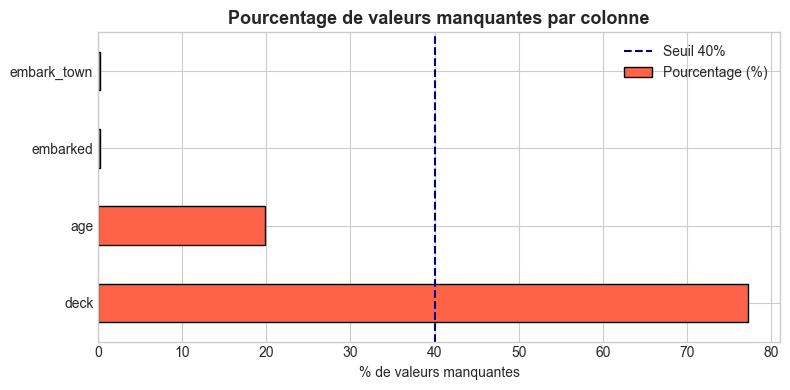

In [4]:
# ÉTAPE 2 : ANALYSE DES VALEURS MANQUANTES


missing = pd.DataFrame({
    'Valeurs manquantes': df.isnull().sum(),
    'Pourcentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage (%)', ascending=False)

missing = missing[missing['Valeurs manquantes'] > 0]

print("=" * 50)
print("VALEURS MANQUANTES PAR COLONNE")
print("=" * 50)
print(missing)

# Visualisation 
fig, ax = plt.subplots(figsize=(8, 4))
missing['Pourcentage (%)'].plot(kind='barh', ax=ax, color='tomato', edgecolor='black')
ax.set_title('Pourcentage de valeurs manquantes par colonne', fontsize=13, fontweight='bold')
ax.set_xlabel('% de valeurs manquantes')
ax.axvline(x=40, color='navy', linestyle='--', label='Seuil 40%')
ax.legend()
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()


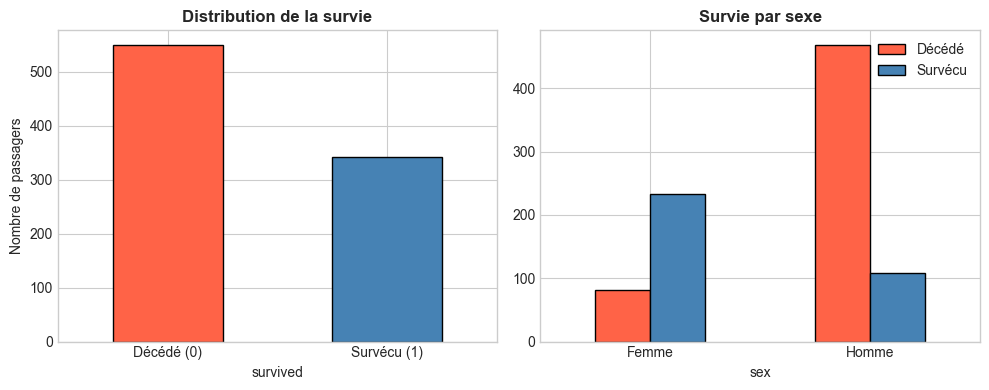


Taux de survie : 38.4% | Taux de décès : 61.6%
→ Déséquilibre modéré, acceptable pour une classification standard.


In [5]:
# ÉTAPE 3 : DISTRIBUTION DE LA VARIABLE CIBLE

# Pourquoi ? Un déséquilibre de classes (ex: 90% vs 10%) biaise
# le modèle qui va simplement prédire toujours la classe majoritaire.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Distribution absolue
df['survived'].value_counts().plot(kind='bar', ax=axes[0], 
                                    color=['tomato', 'steelblue'], edgecolor='black')
axes[0].set_title('Distribution de la survie', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Décédé (0)', 'Survécu (1)'], rotation=0)
axes[0].set_ylabel('Nombre de passagers')

# Distribution par sexe
pd.crosstab(df['sex'], df['survived']).plot(kind='bar', ax=axes[1],
                                             color=['tomato', 'steelblue'], edgecolor='black')
axes[1].set_title('Survie par sexe', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Femme', 'Homme'], rotation=0)
axes[1].legend(['Décédé', 'Survécu'])

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

taux = df['survived'].value_counts(normalize=True) * 100
print(f"\nTaux de survie : {taux[1]:.1f}% | Taux de décès : {taux[0]:.1f}%")
print("→ Déséquilibre modéré, acceptable pour une classification standard.")

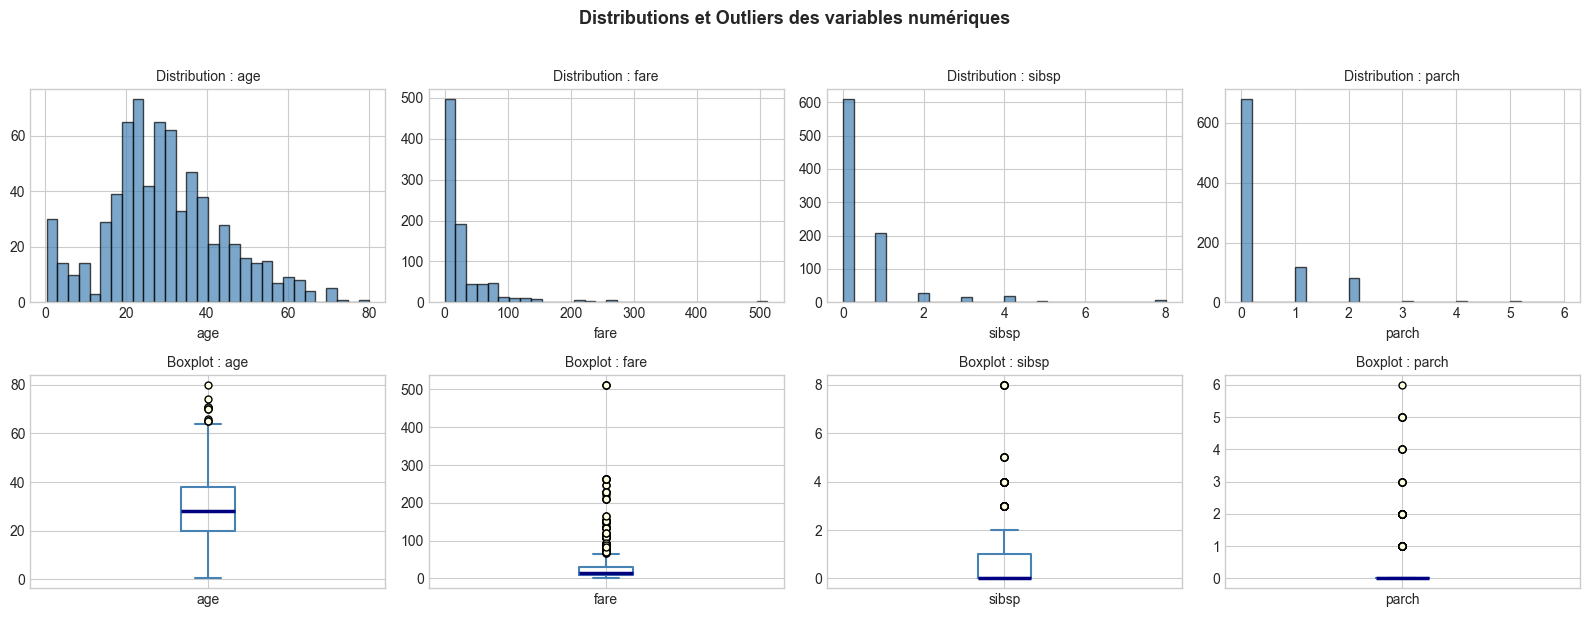


 Observations :
  - 'fare' est très asymétrique à droite (skewed) → présence d'outliers
  - 'age' suit approximativement une distribution normale
  - → Pour 'fare', RobustScaler est préférable (résistant aux outliers)


In [6]:
# ÉTAPE 4 : EXPLORATION DES VARIABLES NUMÉRIQUES

# On visualise les distributions pour détecter :
# - La forme (normale, asymétrique, bimodale)
# - Les outliers (valeurs extrêmes)
# Ces informations guident le choix du scaler !

num_cols = ['age', 'fare', 'sibsp', 'parch']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, col in enumerate(num_cols):
    # Histogramme
    df[col].hist(ax=axes[0, i], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'Distribution : {col}', fontsize=10)
    axes[0, i].set_xlabel(col)
    
    # Boxplot pour les outliers
   # APRÈS (boîte bleu ciel visible)
    df.boxplot(column=col, ax=axes[1, i],
           boxprops=dict(color='steelblue', linewidth=1.5),
           medianprops=dict(color='navy', linewidth=2.5),
           whiskerprops=dict(color='steelblue', linewidth=1.5),
           capprops=dict(color='steelblue', linewidth=1.5),
           flierprops=dict(marker='o', color='steelblue', markerfacecolor='lightyellow',
                           markersize=5, linewidth=1))
    axes[1, i].set_title(f'Boxplot : {col}', fontsize=10)

plt.suptitle('Distributions et Outliers des variables numériques', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Observations :")
print("  - 'fare' est très asymétrique à droite (skewed) → présence d'outliers")
print("  - 'age' suit approximativement une distribution normale")
print("  - → Pour 'fare', RobustScaler est préférable (résistant aux outliers)")

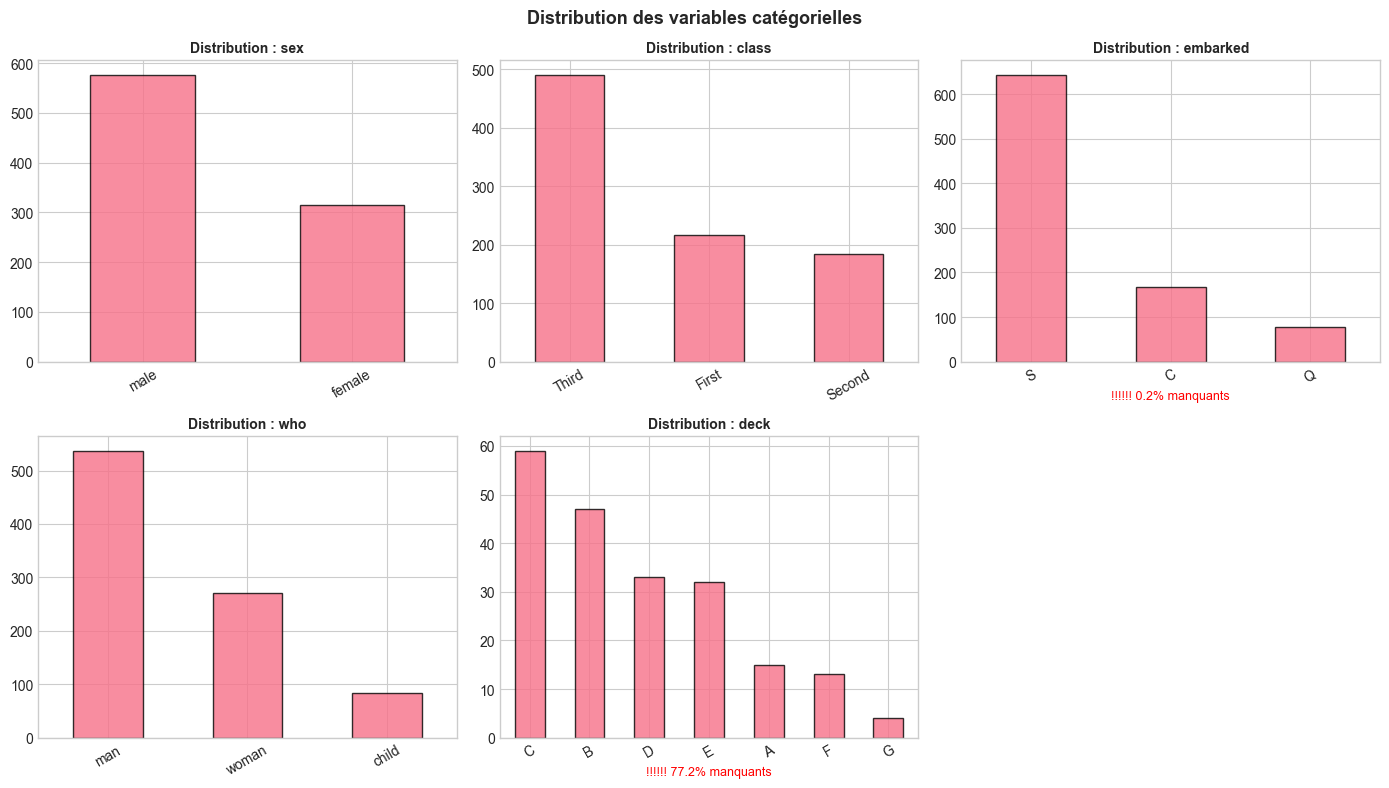

In [7]:
# ÉTAPE 5 : EXPLORATION DES VARIABLES CATÉGORIELLES

cat_cols = ['sex', 'class', 'embarked', 'who', 'deck']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col in df.columns:
        counts = df[col].value_counts()
        counts.plot(kind='bar', ax=axes[i], edgecolor='black', alpha=0.8)
        axes[i].set_title(f'Distribution : {col}', fontsize=10, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=30)
        
        # Affichage des % de valeurs manquantes
        pct_missing = df[col].isnull().mean() * 100
        if pct_missing > 0:
            axes[i].set_xlabel(f'!!!!!! {pct_missing:.1f}% manquants', color='red', fontsize=9)

axes[-1].axis('off')  # Masquer le dernier subplot vide
plt.suptitle('Distribution des variables catégorielles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

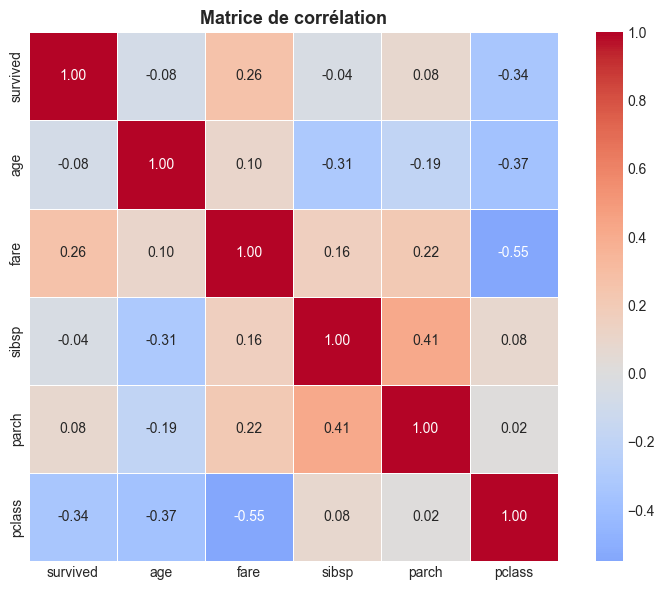


      Interprétation :
  - pclass ↔ survived : corrélation négative (-0.34) → les 1ère classe survivent plus
  - fare ↔ pclass : corrélation négative (-0.55) → 1ère classe = tarifs plus élevés (cohérent)
  - sibsp ↔ parch : légèrement corrélés (0.41) → familles voyagent ensemble


In [8]:
# ÉTAPE 6 : MATRICE DE CORRÉLATION

# La corrélation mesure la relation LINÉAIRE entre variables numériques.
# Valeurs entre -1 (corrélation négative parfaite) et +1 (corrélation positive parfaite)
# 0 = pas de corrélation linéaire

fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df[['survived', 'age', 'fare', 'sibsp', 'parch', 'pclass']].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Matrice de corrélation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n      Interprétation :")
print("  - pclass ↔ survived : corrélation négative (-0.34) → les 1ère classe survivent plus")
print("  - fare ↔ pclass : corrélation négative (-0.55) → 1ère classe = tarifs plus élevés (cohérent)")
print("  - sibsp ↔ parch : légèrement corrélés (0.41) → familles voyagent ensemble")

In [9]:
# SÉLECTION DES FEATURES ET DÉFINITION DE LA CIBLE

# Colonnes à supprimer (justifiées ci-dessus)
cols_to_drop = ['deck', 'who', 'alone', 'adult_male', 'embark_town', 'class', 'alive']

df_clean = df.drop(columns=cols_to_drop)

# Séparation features (X) et cible (y)
X = df_clean.drop(columns=['survived'])
y = df_clean['survived']

print(f"Dimensions de X : {X.shape}")
print(f"Dimensions de y : {y.shape}")
print(f"\nColonnes retenues : {list(X.columns)}")

# Identification des types de colonnes pour le ColumnTransformer
numerical_features = ['age', 'fare', 'sibsp', 'parch']
nominal_features = ['sex', 'embarked']
ordinal_features = ['pclass']  # 1 > 2 > 3 (ordre inversé : 1ère classe = meilleure)

print(f"\n Variables numériques : {numerical_features}")
print(f" Variables nominales   : {nominal_features}")
print(f" Variables ordinales   : {ordinal_features}")

Dimensions de X : (891, 7)
Dimensions de y : (891,)

Colonnes retenues : ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

 Variables numériques : ['age', 'fare', 'sibsp', 'parch']
 Variables nominales   : ['sex', 'embarked']
 Variables ordinales   : ['pclass']


In [10]:
# SPLIT TRAIN / TEST avant prétraitement pour éviter la fuite de données

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # Reproductibilité
    stratify=y           # Préserve la distribution de la cible
)

print(f"Taille du train set : {X_train.shape[0]} exemples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Taille du test set  : {X_test.shape[0]} exemples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nDistribution de y_train : {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Distribution de y_test  : {y_test.value_counts(normalize=True).round(3).to_dict()}")
print("\n Distributions similaires grâce à stratify=y")

Taille du train set : 712 exemples (80%)
Taille du test set  : 179 exemples (20%)

Distribution de y_train : {0: 0.617, 1: 0.383}
Distribution de y_test  : {0: 0.615, 1: 0.385}

 Distributions similaires grâce à stratify=y


In [11]:
# CONSTRUCTION DU COLUMNTRANSFORMER

# --- Flux 1 : Variables numériques ---
# Pipeline séquentiel : d'abord imputer, puis scaler
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Médiane : robuste aux outliers
    ('scaler', StandardScaler())                    # Centrage-réduction
])

# --- Flux 2 : Variables nominales (sans ordre) ---
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),   # Mode
    ('onehot', OneHotEncoder(drop='first',                  # Évite multicolinéarité
                              handle_unknown='ignore',      # Sécurité : nouvelles catégories
                              sparse_output=False))         # Retourne un tableau dense
])

# --- Flux 3 : Variables ordinales (avec ordre) ---
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[[1, 2, 3]]))    # Ordre explicite 
])

# --- Assemblage avec ColumnTransformer ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('nom', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features)
    ],
    remainder='drop'  # Les colonnes non spécifiées sont ignorées
)


print("\n     Structure du prétraitement avec ColumnTransformer:")
print(f"  Flux 1 (num) → {numerical_features}")
print(f"  Flux 2 (nom) → {nominal_features}")
print(f"  Flux 3 (ord) → {ordinal_features}")


     Structure du prétraitement avec ColumnTransformer:
  Flux 1 (num) → ['age', 'fare', 'sibsp', 'parch']
  Flux 2 (nom) → ['sex', 'embarked']
  Flux 3 (ord) → ['pclass']


In [12]:
# CONSTRUCTION DES 3 PIPELINES

# Pipeline 1 : Régression Logistique
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Pipeline 2 : Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Pipeline 3 : Gradient Boosting
pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

pipelines = {
    'Régression Logistique': pipeline_lr,
    'Random Forest': pipeline_rf,
    'Gradient Boosting': pipeline_gb
}

print("       3 pipelines créés :")
for name in pipelines:
    print(f"  - {name}")

       3 pipelines créés :
  - Régression Logistique
  - Random Forest
  - Gradient Boosting


Régression Logistique          | CV Accuracy : 0.7978 ± 0.0204
Random Forest                  | CV Accuracy : 0.7922 ± 0.0356
Gradient Boosting              | CV Accuracy : 0.8218 ± 0.0385


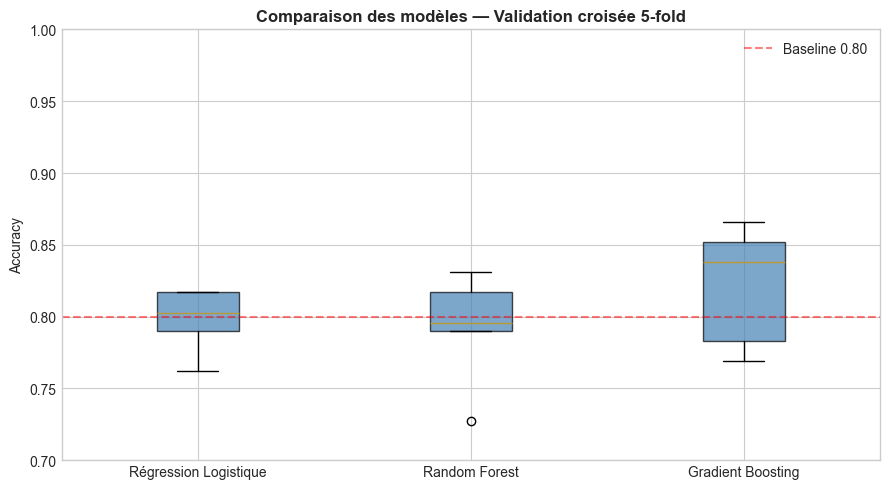

In [13]:
# VALIDATION CROISÉE — Comparaison des 3 pipelines

results = {}

for name, pipeline in pipelines.items():
    # cv=5 : 5-fold cross-validation
    # scoring='accuracy' : métrique d'évaluation
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f"{name:30s} | CV Accuracy : {scores.mean():.4f} ± {scores.std():.4f}")

# Visualisation
fig, ax = plt.subplots(figsize=(9, 5))
data_to_plot = [results[name] for name in results]
bp = ax.boxplot(data_to_plot, patch_artist=True, 
                labels=list(results.keys()),
                boxprops=dict(facecolor='steelblue', alpha=0.7))
ax.set_title('Comparaison des modèles — Validation croisée 5-fold', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.7, 1.0)
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Baseline 0.80')
ax.legend()
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# GRIDSEARCHCV — Optimisation des hyperparamètres
# On optimise le meilleur modèle identifié (Random Forest)

# Grille de paramètres — Notation : 'etape__parametre'
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,    # Utilise tous les cœurs CPU disponibles
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n Meilleurs paramètres : {grid_search.best_params_}")
print(f"\n Meilleur score CV      : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

 Meilleurs paramètres : {'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}

 Meilleur score CV      : 0.8302


In [15]:

# ÉVALUATION FINALE — Test set

best_model = grid_search.best_estimator_

# Prédictions sur le test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]  # Probabilité de la classe 1

print("=" * 60)
print("RÉSULTATS FINAUX — Random Forest optimisé")
print("=" * 60)
print(f"\nAccuracy sur le test set : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC                  : {roc_auc_score(y_test, y_proba):.4f}")
print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred, 
                             target_names=['Décédé (0)', 'Survécu (1)']))

RÉSULTATS FINAUX — Random Forest optimisé

Accuracy sur le test set : 0.7989
ROC-AUC                  : 0.8412

--- Rapport de Classification ---
              precision    recall  f1-score   support

  Décédé (0)       0.79      0.92      0.85       110
 Survécu (1)       0.82      0.61      0.70        69

    accuracy                           0.80       179
   macro avg       0.81      0.76      0.77       179
weighted avg       0.80      0.80      0.79       179



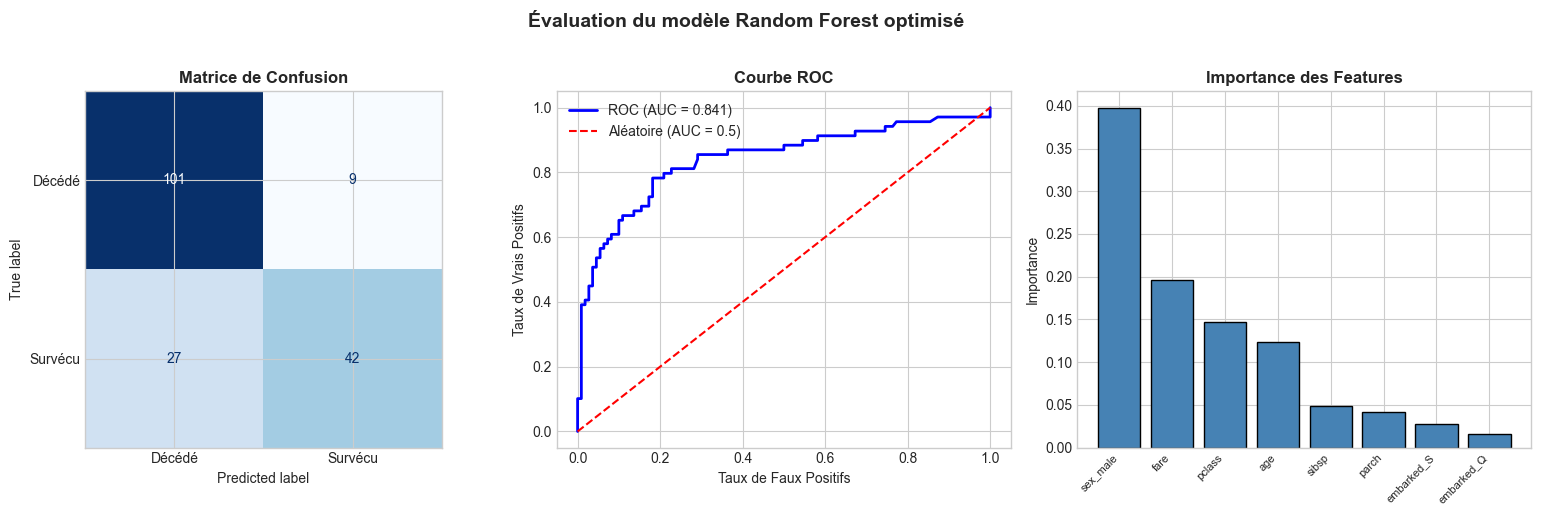

In [16]:
# VISUALISATIONS D'ÉVALUATION

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- 1. Matrice de confusion ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Décédé', 'Survécu'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de Confusion', fontsize=12, fontweight='bold')

# --- 2. Courbe ROC ---
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'r--', label='Aléatoire (AUC = 0.5)')
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs')
axes[1].set_title('Courbe ROC', fontsize=12, fontweight='bold')
axes[1].legend()

# --- 3. Importance des features ---
rf_model = best_model.named_steps['classifier']
feature_names = (
    numerical_features +
    list(best_model.named_steps['preprocessor']
         .named_transformers_['nom']
         .named_steps['onehot']
         .get_feature_names_out(nominal_features)) +
    ordinal_features
)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

axes[2].bar(range(len(importances)), importances[indices], color='steelblue', edgecolor='black')
axes[2].set_xticks(range(len(importances)))
axes[2].set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right', fontsize=8)
axes[2].set_title('Importance des Features', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Importance')

plt.suptitle('Évaluation du modèle Random Forest optimisé', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

##  Comparaison finale des pipelines



In [17]:
# TABLEAU COMPARATIF FINAL

comparison_results = []

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred_temp = pipeline.predict(X_test)
    y_proba_temp = pipeline.predict_proba(X_test)[:, 1]
    
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    
    comparison_results.append({
        'Modèle': name,
        'CV Accuracy (mean)': f"{cv_scores.mean():.4f}",
        'CV Std': f"±{cv_scores.std():.4f}",
        'Test Accuracy': f"{accuracy_score(y_test, y_pred_temp):.4f}",
        'AUC-ROC': f"{roc_auc_score(y_test, y_proba_temp):.4f}"
    })

# Ajouter le RF optimisé
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]
cv_opt = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
comparison_results.append({
    'Modèle': 'RF Optimisé (GridSearchCV)',
    'CV Accuracy (mean)': f"{cv_opt.mean():.4f}",
    'CV Std': f"±{cv_opt.std():.4f}",
    'Test Accuracy': f"{accuracy_score(y_test, y_pred_opt):.4f}",
    'AUC-ROC': f"{roc_auc_score(y_test, y_proba_opt):.4f}"
})

df_comparison = pd.DataFrame(comparison_results)
print("=" * 80)
print("TABLEAU COMPARATIF FINAL")
print("=" * 80)
print(df_comparison.to_string(index=False))

TABLEAU COMPARATIF FINAL
                    Modèle CV Accuracy (mean)  CV Std Test Accuracy AUC-ROC
     Régression Logistique             0.7978 ±0.0204        0.8045  0.8437
             Random Forest             0.7922 ±0.0356        0.8101  0.8354
         Gradient Boosting             0.8218 ±0.0385        0.7989  0.8179
RF Optimisé (GridSearchCV)             0.8302 ±0.0492        0.7989  0.8412


---
# PARTIE II — Données Textuelles : 20 Newsgroups
---



### Simplification pédagogique
Pour ce projet, on se limite à **4 catégories** pour faciliter l'interprétation.

In [18]:
# CHARGEMENT DU CORPUS 20 NEWSGROUPS (4 catégories)

# 4 catégories choisies pour la diversité thématique
categories = [
    'rec.sport.baseball',
    'sci.space',
    'talk.politics.guns',
    'comp.graphics'
]

# remove=['headers', 'footers', 'quotes'] : on enlève les métadonnées
# pour ne garder que le contenu textuel pur (évite la triche)
newsgroups_train = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

newsgroups_test = fetch_20newsgroups(
    subset='test',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

X_text_train = newsgroups_train.data
y_text_train = newsgroups_train.target
X_text_test  = newsgroups_test.data
y_text_test  = newsgroups_test.target

print(f"Taille train : {len(X_text_train)} documents")
print(f"Taille test  : {len(X_text_test)} documents")
print(f"\nCatégories :")
for i, cat in enumerate(newsgroups_train.target_names):
    count = (y_text_train == i).sum()
    print(f"  {i} - {cat} : {count} documents")
    
print(f"\nExemple de document (extrait) :\n{X_text_train[0][:300]}...")

Taille train : 2320 documents
Taille test  : 1544 documents

Catégories :
  0 - comp.graphics : 584 documents
  1 - rec.sport.baseball : 597 documents
  2 - sci.space : 593 documents
  3 - talk.politics.guns : 546 documents

Exemple de document (extrait) :

What about guns with non-lethal bullets, like rubber or plastic bullets. Would
those work very well in stopping an attack?...


In [19]:
# REPRÉSENTATION 1 : CountVectorizer

count_vectorizer = CountVectorizer(
    max_features=10000,   # On garde les 10 000 mots les plus fréquents
    stop_words='english', # On supprime les mots vides ("the", "is", "at", ...)
    min_df=2              # Un mot doit apparaître dans au moins 2 documents
)

# IMPORTANT : fit sur train, transform sur train ET test
X_count_train = count_vectorizer.fit_transform(X_text_train)
X_count_test  = count_vectorizer.transform(X_text_test)

print("CountVectorizer")
print(f"  Taille de la matrice train : {X_count_train.shape}")
print(f"  Densité : {X_count_train.nnz / (X_count_train.shape[0]*X_count_train.shape[1])*100:.2f}%")
print(f"  → La matrice est creuse à {100 - X_count_train.nnz / (X_count_train.shape[0]*X_count_train.shape[1])*100:.2f}%")
print(f"\n  Exemple de 10 premiers mots du vocabulaire :")
print(f"  {list(count_vectorizer.vocabulary_.keys())[:10]}")

CountVectorizer
  Taille de la matrice train : (2320, 10000)
  Densité : 0.55%
  → La matrice est creuse à 99.45%

  Exemple de 10 premiers mots du vocabulaire :
  ['guns', 'non', 'lethal', 'bullets', 'like', 'rubber', 'plastic', 'work', 'stopping', 'attack']


In [20]:
# REPRÉSENTATION 2 : TF-IDF

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    min_df=2,
    ngram_range=(1, 2)  # Unigrammes ET bigrammes (ex: "space exploration")
)

X_tfidf_train = tfidf_vectorizer.fit_transform(X_text_train)
X_tfidf_test  = tfidf_vectorizer.transform(X_text_test)

print("TF-IDF avec bigrammes")
print(f"  Taille de la matrice train : {X_tfidf_train.shape}")
print(f"  Densité : {X_tfidf_train.nnz / (X_tfidf_train.shape[0]*X_tfidf_train.shape[1])*100:.3f}%")

# Afficher les 10 mots les plus importants par catégorie
print("\n  Top 5 mots TF-IDF par catégorie :")
feature_names = tfidf_vectorizer.get_feature_names_out()

for i, cat in enumerate(newsgroups_train.target_names):
    # Moyenne TF-IDF pour les docs de cette catégorie
    cat_mask = (y_text_train == i)
    cat_tfidf = X_tfidf_train[cat_mask].mean(axis=0).A1
    top_indices = cat_tfidf.argsort()[-5:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    print(f"  {cat:30s} → {top_words}")

TF-IDF avec bigrammes
  Taille de la matrice train : (2320, 10000)
  Densité : 0.571%

  Top 5 mots TF-IDF par catégorie :
  comp.graphics                  → ['graphics', 'thanks', 'image', 'files', 'file']
  rec.sport.baseball             → ['year', 'team', 'game', 'baseball', 'games']
  sci.space                      → ['space', 'nasa', 'like', 'just', 'orbit']
  talk.politics.guns             → ['gun', 'people', 'guns', 'don', 'fbi']


In [21]:

# REPRÉSENTATION 3 : HashingVectorizer

# Avantage : pas de vocabulaire stocké en mémoire → scalable
# Inconvénient : pas d'IDF, collisions possibles

hashing_vectorizer = HashingVectorizer(
    n_features=2**16,  # 65536 dimensions (puissance de 2 pour efficacité)
    stop_words='english',
    alternate_sign=False  # Pour compatibilité avec MultinomialNB (valeurs ≥ 0)
)

# HashingVectorizer n'a pas de fit() — pas de dictionnaire appris
X_hash_train = hashing_vectorizer.transform(X_text_train)
X_hash_test  = hashing_vectorizer.transform(X_text_test)

print("HashingVectorizer")
print(f"  Taille de la matrice train : {X_hash_train.shape}")
print(f"  Avantage : pas de vocabulaire fixe → traitement de nouveaux docs illimité")
print(f"  Inconvénient : pas de get_feature_names() → interprétabilité limitée")

HashingVectorizer
  Taille de la matrice train : (2320, 65536)
  Avantage : pas de vocabulaire fixe → traitement de nouveaux docs illimité
  Inconvénient : pas de get_feature_names() → interprétabilité limitée


In [22]:
# PIPELINES TEXTUELS — Comparaison des représentations

# Pipeline A : CountVectorizer + Naive Bayes
pipe_count_nb = Pipeline([
    ('vect', CountVectorizer(max_features=10000, stop_words='english', min_df=2)),
    ('clf',  MultinomialNB())
])

# Pipeline B : TF-IDF (unigrammes) + Naive Bayes
pipe_tfidf_nb = Pipeline([
    ('vect', TfidfVectorizer(max_features=10000, stop_words='english', min_df=2)),
    ('clf',  MultinomialNB())
])

# Pipeline C : TF-IDF (bigrammes) + Régression Logistique
pipe_tfidf_lr = Pipeline([
    ('vect', TfidfVectorizer(max_features=10000, stop_words='english', 
                              min_df=2, ngram_range=(1, 2))),
    ('clf',  LogisticRegression(max_iter=1000, random_state=42))
])

text_pipelines = {
    'CountVect + NaiveBayes': pipe_count_nb,
    'TF-IDF (1-gram) + NaiveBayes': pipe_tfidf_nb,
    'TF-IDF (1-2gram) + LogReg': pipe_tfidf_lr
}

text_results = []

for name, pipe in text_pipelines.items():
    pipe.fit(X_text_train, y_text_train)
    y_pred_text = pipe.predict(X_text_test)
    acc = accuracy_score(y_text_test, y_pred_text)
    text_results.append({'Pipeline': name, 'Accuracy': f"{acc:.4f}"})
    print(f"{name:40s} | Accuracy : {acc:.4f}")

print("\n Meilleur pipeline textuel identifié.")

CountVect + NaiveBayes                   | Accuracy : 0.8912
TF-IDF (1-gram) + NaiveBayes             | Accuracy : 0.8925
TF-IDF (1-2gram) + LogReg                | Accuracy : 0.8731

 Meilleur pipeline textuel identifié.


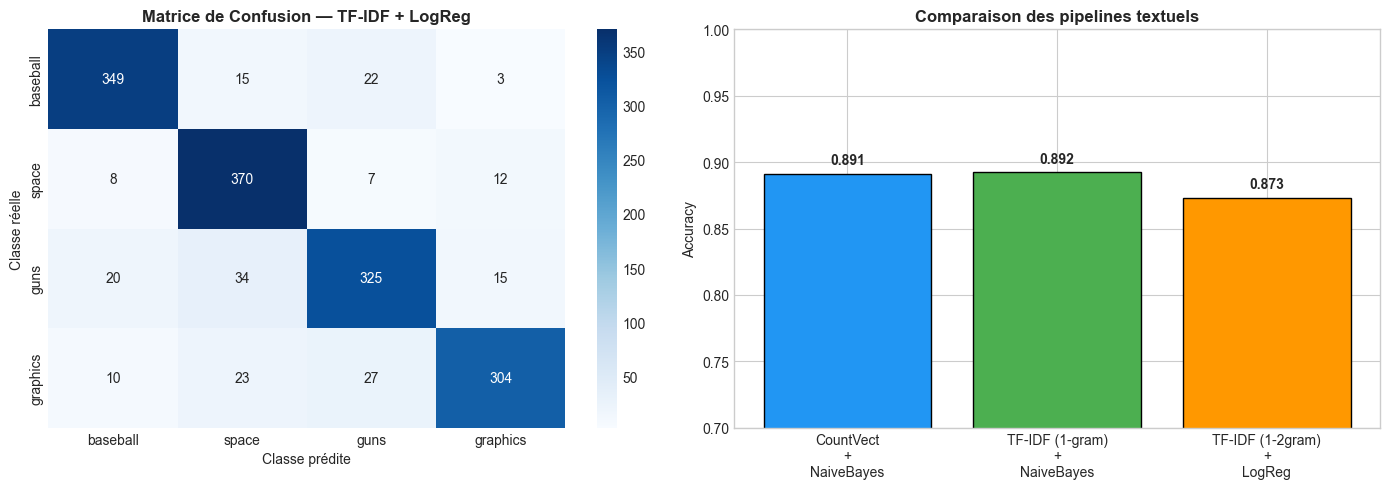


Rapport de classification détaillé (TF-IDF + LogReg) :
              precision    recall  f1-score   support

    baseball       0.90      0.90      0.90       389
       space       0.84      0.93      0.88       397
        guns       0.85      0.82      0.84       394
    graphics       0.91      0.84      0.87       364

    accuracy                           0.87      1544
   macro avg       0.88      0.87      0.87      1544
weighted avg       0.87      0.87      0.87      1544



In [23]:
# VISUALISATION DES RÉSULTATS TEXTUELS

# Rapport détaillé sur le meilleur pipeline
best_text_pipe = pipe_tfidf_lr
y_pred_best = best_text_pipe.predict(X_text_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm_text = confusion_matrix(y_text_test, y_pred_best)
sns.heatmap(cm_text, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[c.split('.')[-1] for c in categories],
            yticklabels=[c.split('.')[-1] for c in categories])
axes[0].set_title('Matrice de Confusion — TF-IDF + LogReg', 
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Classe réelle')
axes[0].set_xlabel('Classe prédite')

# Comparaison des pipelines
names = [r['Pipeline'].replace(' + ', '\n+\n') for r in text_results]
accs = [float(r['Accuracy']) for r in text_results]
bars = axes[1].bar(names, accs, color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='black')
axes[1].set_title('Comparaison des pipelines textuels', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.7, 1.0)
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('text_classification_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRapport de classification détaillé (TF-IDF + LogReg) :")
print(classification_report(y_text_test, y_pred_best,
                             target_names=[c.split('.')[-1] for c in categories]))

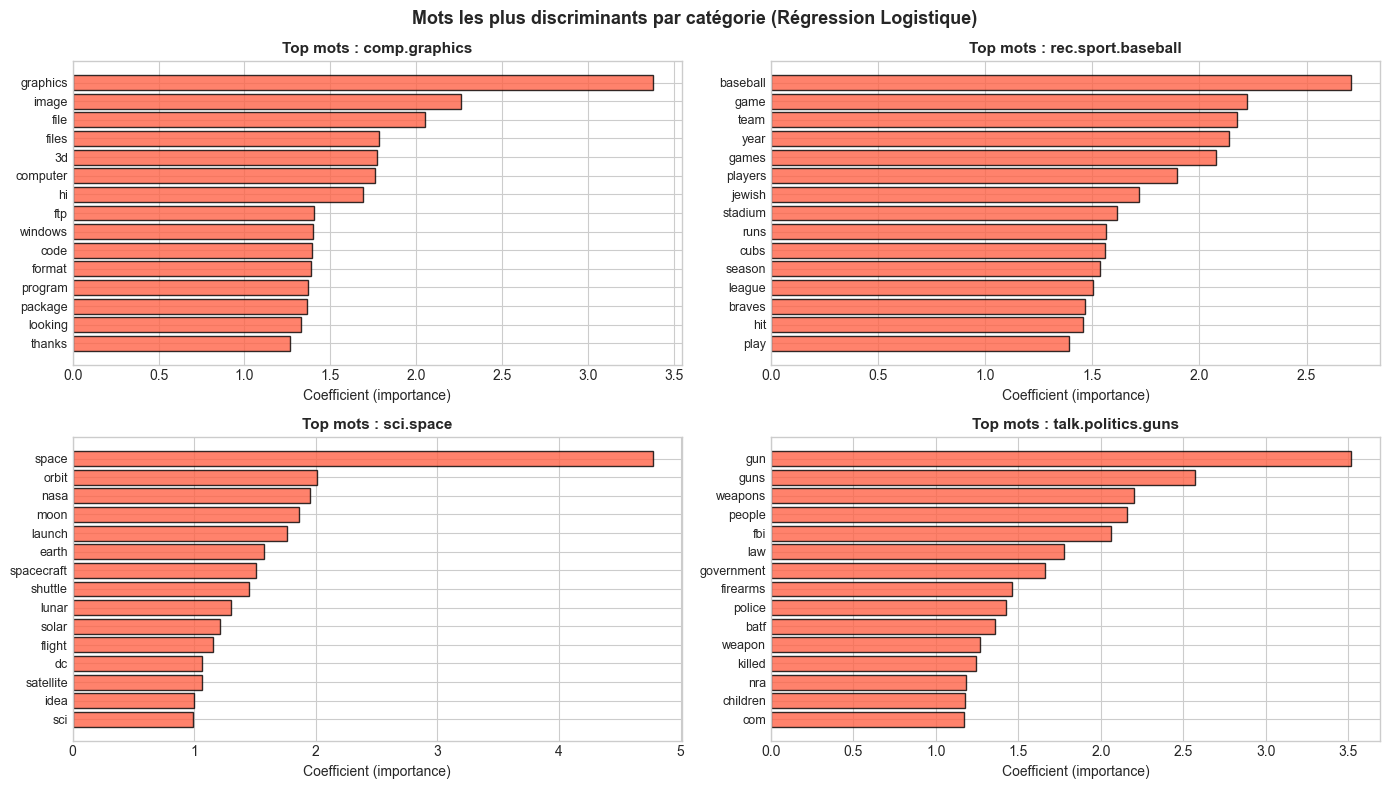

In [24]:
# INSPECTION DU MODÈLE : Top mots par catégorie (LogReg)

lr_model = best_text_pipe.named_steps['clf']
tfidf_model = best_text_pipe.named_steps['vect']
feature_names_text = tfidf_model.get_feature_names_out()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

# newsgroups_train.target_names est trié alphabétiquement
# MÊME ordre que lr_model.coef_[i]
# ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.guns']

titres = {
    'comp.graphics':       'comp.graphics',
    'rec.sport.baseball':  'rec.sport.baseball',
    'sci.space':           'sci.space',
    'talk.politics.guns':  'talk.politics.guns'
}

for i, (class_name, ax) in enumerate(zip(newsgroups_train.target_names, axes)):
    coefs = lr_model.coef_[i]
    top_indices = coefs.argsort()[-15:][::-1]
    top_words = [feature_names_text[j] for j in top_indices]
    top_coefs = coefs[top_indices]

    colors = ['tomato' if c > 0 else 'steelblue' for c in top_coefs]
    ax.barh(range(15), top_coefs[::-1], color=colors[::-1], edgecolor='black', alpha=0.8)
    ax.set_yticks(range(15))
    ax.set_yticklabels(top_words[::-1], fontsize=9)
    ax.set_title(f'Top mots : {class_name}', fontsize=11, fontweight='bold')  # nom complet
    ax.set_xlabel('Coefficient (importance)')

plt.suptitle('Mots les plus discriminants par catégorie (Régression Logistique)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('top_words_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

---
# CONCLUSION SYNTHÉTIQUE
---

## Apports du projet

### Partie I — Données tabulaires (Titanic)
1. **Inspection rigoureuse** : identification des types de variables, des valeurs manquantes, des distributions
2. **ColumnTransformer** : application de traitements distincts aux variables numériques (médiane + StandardScaler), nominales (mode + OHE) et ordinales (mode + OrdinalEncoder)
3. **Pipelines** : architecture robuste prévenant la fuite de données
4. **Comparaison de 3 modèles** + optimisation par GridSearchCV
5. **Évaluation complète** : accuracy, ROC-AUC, matrice de confusion, importance des features

### Partie II — Données textuelles (20 Newsgroups)
1. **3 représentations comparées** : CountVectorizer, TF-IDF, HashingVectorizer
2. **Impact des n-grammes** : les bigrammes capturent des expressions composées informatives
3. **Inspection du modèle** : identification des mots discriminants par classe

## Limites
- Dataset Titanic : taille limitée (891 exemples), certaines informations absentes (personnalité, santé)
- TF-IDF : ne capture pas la sémantique ("chien" et "canidé" = deux mots différents pour TF-IDF)
- Pas de lemmatisation ni stemming → "running" et "run" comptent séparément

## Prolongements possibles
- Utiliser des **word embeddings** (Word2Vec, FastText) ou des **transformers** (BERT) pour capturer la sémantique
- Appliquer **SHAP** pour une interprétabilité plus fine du Random Forest
- Explorer des techniques d'**augmentation de données** pour les classes minoritaires

In [25]:
# RÉSUMÉ FINAL — Toutes les métriques 

print("=" * 70)
print("RÉSUMÉ COMPLET DU PROJET")
print("=" * 70)

print("\n PARTIE I — Titanic (Classification binaire)")
print("-" * 50)
df_comp_display = pd.DataFrame(comparison_results)
print(df_comp_display.to_string(index=False))

print("\n\n PARTIE II — 20 Newsgroups (Classification multi-classe)")
print("-" * 50)
df_text_display = pd.DataFrame(text_results)
print(df_text_display.to_string(index=False))

print("\n\n Projet terminé. Tous les graphiques ont été sauvegardés.")

RÉSUMÉ COMPLET DU PROJET

 PARTIE I — Titanic (Classification binaire)
--------------------------------------------------
                    Modèle CV Accuracy (mean)  CV Std Test Accuracy AUC-ROC
     Régression Logistique             0.7978 ±0.0204        0.8045  0.8437
             Random Forest             0.7922 ±0.0356        0.8101  0.8354
         Gradient Boosting             0.8218 ±0.0385        0.7989  0.8179
RF Optimisé (GridSearchCV)             0.8302 ±0.0492        0.7989  0.8412


 PARTIE II — 20 Newsgroups (Classification multi-classe)
--------------------------------------------------
                    Pipeline Accuracy
      CountVect + NaiveBayes   0.8912
TF-IDF (1-gram) + NaiveBayes   0.8925
   TF-IDF (1-2gram) + LogReg   0.8731


 Projet terminé. Tous les graphiques ont été sauvegardés.
